## Bank Term Deposit Subscription Prediction

# 🎯 Project Objective

- To build a machine learning model that predicts whether a bank customer will subscribe to a term deposit (Fixed Deposit) based on their demographic details, financial background, and previous marketing campaign interactions — enabling the bank to target the right customers and reduce campaign costs.

# Primary Goals

- Analyze the bank marketing dataset to understand customer behavior and identify patterns that influence term deposit subscription.
- Preprocess the data by handling missing values, encoding categorical variables, and balancing the class distribution.
- Build a Random Forest Classifier model to accurately predict customer subscription (yes/no).
- Evaluate the model using appropriate metrics such as Accuracy Score
- Identify the most important features that influence a customer's decision to subscribe using feature importance analysis.


# SECTION-1. Data Understanding and Cleaning

**1.Importing All Necessary Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn

**2.Loading the Dataset**

In [2]:
df = pd.read_csv("Bank_Marketing.csv", sep=";")


**3.Basic Exploration**

In [3]:
df.shape

(41188, 21)

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**4.Checking Datatypes**

In [7]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

**5.Renaming Column Names for Better Readability**

In [8]:
df.rename(columns={
    'emp.var.rate'  : 'emp_var_rate',
    'cons.price.idx': 'cons_price_idx',
    'cons.conf.idx' : 'cons_conf_idx',
    'nr.employed'   : 'nr_employed',
    'y'             : 'target'
}, inplace=True)

**Insights-**

- Special characters (.) were replaced with (_) for cleaner column names.
- Target column y was renamed to target for better understanding.
- Cleaner column names improve readability and make coding easier during EDA and model building.

**6.Seperating Categorical and Numerical columns**

In [9]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='str')

In [10]:
cat_cols = df.select_dtypes(include="str")
cat_cols

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,target
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes


**7.Handling Misssing Values**

In [11]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
target            0
dtype: int64

- Here we can see no null values.
- Therefore no handling missing values required.

**8.Checking Unknown values**

In [12]:
for col in cat_cols:
    print(col, (df[col] == 'unknown').sum())
    

job 330
marital 80
education 1731
default 8597
housing 990
loan 990
contact 0
month 0
day_of_week 0
poutcome 0
target 0


**Insights:**
- "unknown" values act as missing data in categorical columns.
- default has the highest unknown values (8,596).
- education contains 1,730 unknown values.
- housing and loan each contain 990 unknown values.
- job and marital have very few unknown values.
- contact, month, day_of_week, poutcome, and y contain no unknown values.
- Unknown values should be handled during preprocessing using:
     - mode replacement,
     - separate category handling,
     - or feature removal if necessary.

In [13]:
df.drop('default', axis=1, inplace=True)


- since default column have large number of values dropping the column is best for our further analysis
- Replacing unknown values with mode for the column "job","marital","education","housing","loan".


In [14]:
cols_to_replace = ['job', 'marital', 'education', 'housing', 'loan']
for col in cols_to_replace:
    mode_value = df[col].mode()[0]

    df[col] = df[col].replace('unknown', mode_value)

**9.Handling Duplicate Values**

In [15]:
df.duplicated().sum()

np.int64(14)

- Here we can see 14 duplicates
- so remove them for better analysis

In [16]:
df.drop_duplicates(inplace=True)

- Hence the duplicate values are removed

**10.Cleaning the Categorical Columns**

- I have found some inconsistency in "job" and "education" columns

In [17]:
df['job'].value_counts()

job
admin.           10748
blue-collar       9252
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Name: count, dtype: int64

In [18]:
df['job'] = df['job'].replace('admin.', 'admin')

- replaced "admin." with "admin"

In [19]:
df['education'].value_counts()

education
university.degree      13893
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4175
basic.6y                2291
illiterate                18
Name: count, dtype: int64

In [20]:
df['education'] = df['education'].replace({
    'university.degree': 'university_degree',
    'high.school': 'high_school',
    'professional.course': 'professional_course',
    'basic.4y': 'basic_4y',
    'basic.6y': 'basic_6y',
    'basic.9y': 'basic_9y'
})

- Special characters (.) in education categories were replaced with (_) for better readability.
- Hence, the inconsistent labels are removed.
- This ensures consistency in the dataset and improves analysis accuracy.

**11.Final validation**

A. Checking the data shape

In [21]:
print("Shape after cleaning:", df.shape)


Shape after cleaning: (41174, 20)


B. Checking the datatypes

In [22]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp_var_rate      float64
cons_price_idx    float64
cons_conf_idx     float64
euribor3m         float64
nr_employed       float64
target                str
dtype: object

# Feature Selection

### 1) Checking Duplicate Columns

In [23]:
df.T.duplicated().sum()

np.int64(0)

- No duplicate columns were found in the dataset.
- Therefore, no columns needed to be removed.

### 2) Zero Varience or Low Variance

In [24]:
df.nunique()

age                 78
job                 11
marital              3
education            7
housing              2
loan                 2
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp_var_rate        10
cons_price_idx      26
cons_conf_idx       26
euribor3m          316
nr_employed         11
target               2
dtype: int64

In [25]:
for i in df.columns:
    print(df[i].value_counts())

age
31    1947
32    1845
33    1832
36    1779
35    1758
      ... 
98       2
89       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
job
admin            10748
blue-collar       9252
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Name: count, dtype: int64
marital
married     24999
single      11564
divorced     4611
Name: count, dtype: int64
education
university_degree      13893
high_school             9512
basic_9y                6045
professional_course     5240
basic_4y                4175
basic_6y                2291
illiterate                18
Name: count, dtype: int64
housing
yes    22560
no     18614
Name: count, dtype: int64
loan
no     34926
yes     6248
Name: count, dtype: int64
contact
cellular     26134
telephone    15040
Name: count, dtype: int64
month
may    13766
jul     7169
aug   

- Since all columns contain more than one class/category, no column was excluded based on low variability.
- Therefore, no columns needed to be dropped during preprocessing.

**Data set is cleaned:**

- All data types are correctly assigned.
- The dataset is clean and ready for further analysis.

# SECTION-2. Exploratory Data Analysis

# **1.Target Variable Distribution**

- Analyze customer subscription distribution 

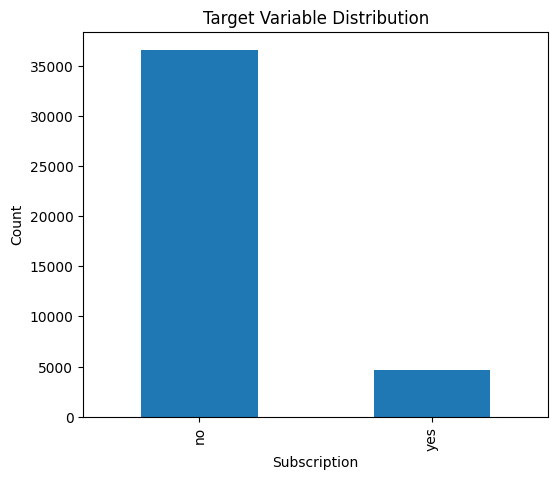

In [26]:
df['target'].value_counts().plot(kind='bar',figsize=(6,5))
plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")

plt.show()

**Insights-**

- Majority of customers did not subscribe to the term deposit.

- Very few customers subscribed successfully.

- Dataset is highly imbalanced.

- Imbalanced data may affect machine learning model performance.

# **2.Age Distribution Analysis**

- Understanding customer age distribution.

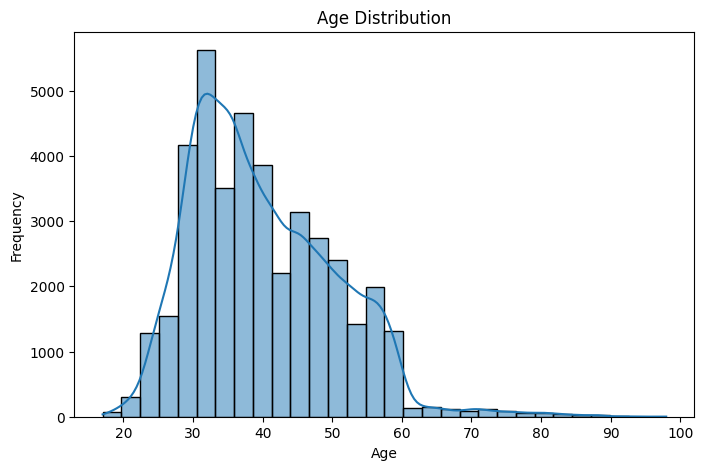

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insights-**

- Most customers are between 30–45 years old.

- Younger and middle-aged customers dominate the dataset.

- Very few senior customers are present.

- Distribution is slightly right-skewed.

# **3.Correlation Heatmap**

- Identify relationships between numerical features.

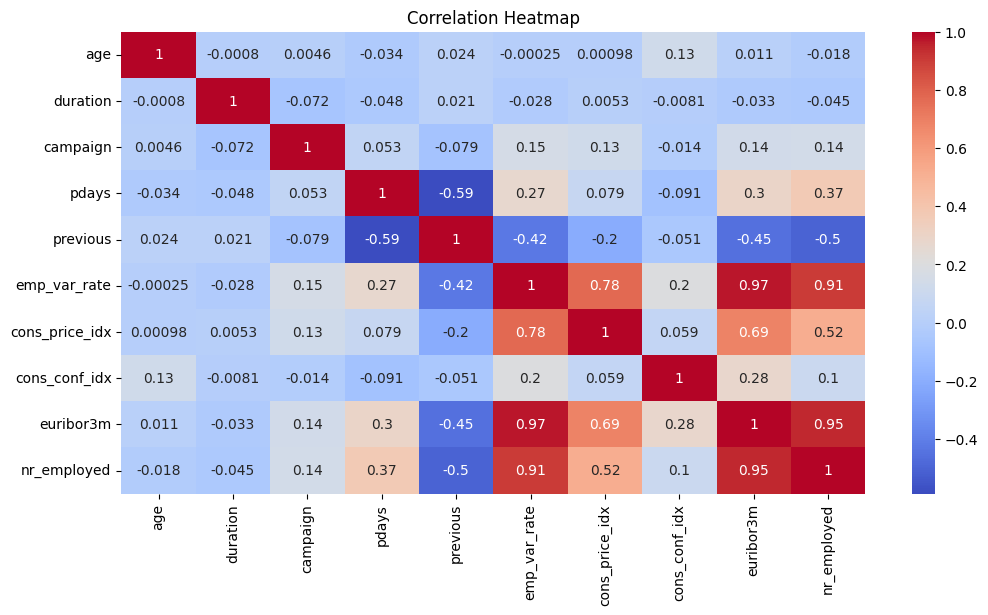

In [28]:
plt.figure(figsize=(12,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Insights-**

- Strong positive correlation exists between economic indicator features.

- euribor3m, emp_var_rate, and nr_employed are highly correlated.

- duration shows strong influence on customer subscription.

- Multicollinearity may exist among some numerical variables.

# **4.Job vs Subscription Analysis**

- Analyze subscription trends across job categories.

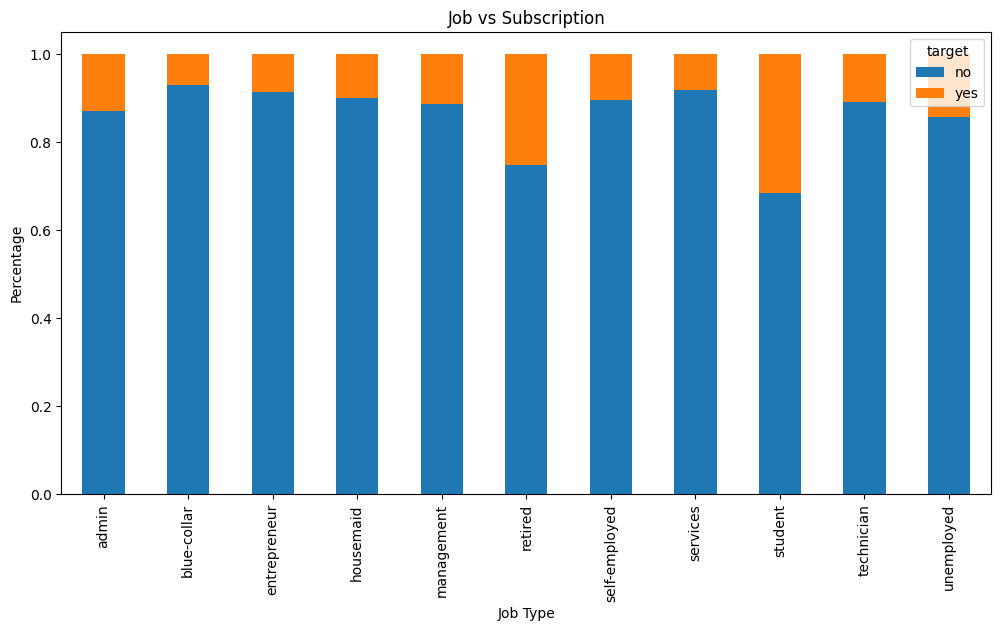

In [29]:
pd.crosstab(df['job'],df['target'],normalize='index').plot(kind='bar',
stacked=True,figsize=(12,6))
plt.title("Job vs Subscription")
plt.xlabel("Job Type")
plt.ylabel("Percentage")
plt.show()

**Insights-**

- Students and retired customers have higher subscription rates.

- Blue-collar customers show lower subscription rates.

- Customer profession significantly affects marketing campaign success.

- Certain job groups are more likely to subscribe to bank deposits.

# Summary:

- Dataset contains severe class imbalance.

- Age plays an important role in customer targeting.

- Economic indicators strongly influence subscription behavior.

- Job category impacts campaign success rate.

# SECTION 3 — Data Preprocessing

**1.Check Unique Values in Each Column**

In [30]:
for i in df:
    print(f"*****{i}******")
    print(df[i].unique())

*****age******
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
*****job******
<ArrowStringArray>
[    'housemaid',      'services',         'admin',   'blue-collar',
    'technician',       'retired',    'management',    'unemployed',
 'self-employed',  'entrepreneur',       'student']
Length: 11, dtype: str
*****marital******
<ArrowStringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
*****education******
<ArrowStringArray>
[           'basic_4y',         'high_school',            'basic_6y',
            'basic_9y', 'professional_course',   'university_degree',
          'illiterate']
Length: 7, dtype: str
*****housing******
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
*****loan******
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
*****contact******
<ArrowStringArr

**2. Create Previously Contacted Feature from pday**

In [31]:
df['previously_contacted'] = np.where(df['pdays'] == 999, 0, 1)

**3.  Droping pdays Column**

In [32]:
df.drop('pdays', axis=1, inplace=True)

**4. Splitting the data into Inputs(Features) and Output(Target variable)**

In [33]:
df.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome',
       'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m',
       'nr_employed', 'target', 'previously_contacted'],
      dtype='str')

In [34]:
X = df.drop("target",axis=1)
y = df["target"]

In [35]:
X

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previously_contacted
0,56,housemaid,married,basic_4y,no,no,telephone,may,mon,261,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high_school,no,no,telephone,may,mon,149,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high_school,yes,no,telephone,may,mon,226,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin,married,basic_6y,no,no,telephone,may,mon,151,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high_school,no,yes,telephone,may,mon,307,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional_course,yes,no,cellular,nov,fri,334,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41184,46,blue-collar,married,professional_course,no,no,cellular,nov,fri,383,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university_degree,yes,no,cellular,nov,fri,189,2,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional_course,no,no,cellular,nov,fri,442,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0


In [36]:
y

0         no
1         no
2         no
3         no
4         no
        ... 
41183    yes
41184     no
41185     no
41186    yes
41187     no
Name: target, Length: 41174, dtype: str

# Holdout Validation Strategy

- Splitting the input and output into train and test (80%,20%)
- Since the dataset is large, the **Holdout Validation strategy** was used for model evaluation, as it provides an efficient and reliable estimate of model performance.
- The test set consists of 20% of the data, which is sufficiently large to represent the overall data distribution. Therefore, the likelihood of missing important patterns in the test set is minimal.

In [37]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=45)

In [38]:
X_train

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previously_contacted
10798,32,self-employed,divorced,professional_course,yes,no,telephone,jun,wed,235,3,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,0
25955,39,admin,married,university_degree,yes,no,cellular,nov,wed,171,2,1,failure,-0.1,93.200,-42.0,4.120,5195.8,0
40092,36,technician,single,university_degree,yes,yes,cellular,jul,mon,305,4,1,success,-1.7,94.215,-40.3,0.827,4991.6,1
11470,37,housemaid,married,high_school,no,yes,telephone,jun,fri,31,1,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
24681,41,entrepreneur,married,university_degree,yes,no,cellular,nov,mon,44,2,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32480,29,blue-collar,married,basic_9y,no,no,cellular,may,fri,128,3,1,failure,-1.8,92.893,-46.2,1.313,5099.1,0
16321,35,services,single,high_school,yes,yes,telephone,jul,tue,1148,2,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0
12898,43,technician,single,professional_course,no,no,cellular,jul,tue,97,6,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
6014,32,blue-collar,married,professional_course,yes,no,telephone,may,tue,128,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [39]:
y_train

10798    no
25955    no
40092    no
11470    no
24681    no
         ..
32480    no
16321    no
12898    no
6014     no
6560     no
Name: target, Length: 32939, dtype: str

In [40]:
X_test

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previously_contacted
38440,24,admin,single,university_degree,yes,yes,telephone,oct,thu,97,1,0,nonexistent,-3.4,92.431,-26.9,0.733,5017.5,0
34276,33,admin,married,professional_course,no,yes,cellular,may,thu,178,8,1,failure,-1.8,92.893,-46.2,1.266,5099.1,0
25796,31,blue-collar,married,basic_9y,no,no,cellular,nov,wed,96,1,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0
16774,50,entrepreneur,married,basic_9y,yes,no,cellular,jul,thu,129,1,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
30720,58,admin,single,university_degree,no,no,cellular,may,tue,358,1,0,nonexistent,-1.8,92.893,-46.2,1.344,5099.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14274,52,services,married,high_school,no,no,cellular,jul,mon,76,2,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
34764,30,technician,married,basic_9y,yes,no,cellular,may,thu,181,4,0,nonexistent,-1.8,92.893,-46.2,1.266,5099.1,0
28947,32,management,single,university_degree,yes,no,cellular,apr,fri,709,1,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
35396,32,admin,single,professional_course,yes,yes,telephone,may,fri,73,4,0,nonexistent,-1.8,92.893,-46.2,1.250,5099.1,0


In [41]:
y_test

38440    yes
34276     no
25796     no
16774     no
30720     no
        ... 
14274     no
34764     no
28947    yes
35396     no
24408     no
Name: target, Length: 8235, dtype: str

# Feature Engineering

**Transform X_train and y_train into Numerical Using Encoding and Scaling Techniques**

**1) Transforming X_train**

- TO transform we need to split the X_train into categorical,numerical,no trans to apply Encoding Techniques.

In [42]:
cat_Xtrain = X_train.select_dtypes(include="str")
cat_Xtrain

,job,marital,education,housing,loan,contact,month,day_of_week,poutcome
10798,self-employed,divorced,professional_course,yes,no,telephone,jun,wed,nonexistent
25955,admin,married,university_degree,yes,no,cellular,nov,wed,failure
40092,technician,single,university_degree,yes,yes,cellular,jul,mon,success
11470,housemaid,married,high_school,no,yes,telephone,jun,fri,nonexistent
24681,entrepreneur,married,university_degree,yes,no,cellular,nov,mon,nonexistent
...,...,...,...,...,...,...,...,...,...
32480,blue-collar,married,basic_9y,no,no,cellular,may,fri,failure
16321,services,single,high_school,yes,yes,telephone,jul,tue,nonexistent
12898,technician,single,professional_course,no,no,cellular,jul,tue,nonexistent
6014,blue-collar,married,professional_course,yes,no,telephone,may,tue,nonexistent


In [43]:
num_Xtrain = X_train.select_dtypes(include=["int64","float64"])
num_Xtrain = num_Xtrain.drop(columns=["previous","previously_contacted"])
num_Xtrain

,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
10798,32,235,3,1.4,94.465,-41.8,4.962,5228.1
25955,39,171,2,-0.1,93.200,-42.0,4.120,5195.8
40092,36,305,4,-1.7,94.215,-40.3,0.827,4991.6
11470,37,31,1,1.4,94.465,-41.8,4.959,5228.1
24681,41,44,2,-0.1,93.200,-42.0,4.191,5195.8
...,...,...,...,...,...,...,...,...
32480,29,128,3,-1.8,92.893,-46.2,1.313,5099.1
16321,35,1148,2,1.4,93.918,-42.7,4.961,5228.1
12898,43,97,6,1.4,93.918,-42.7,4.962,5228.1
6014,32,128,1,1.1,93.994,-36.4,4.857,5191.0


In [44]:
no_trans_Xtrain = X_train[["previous","previously_contacted"]]
no_trans_Xtrain

,previous,previously_contacted
10798,0,0
25955,1,0
40092,1,1
11470,0,0
24681,0,0
...,...,...
32480,1,0
16321,0,0
12898,0,0
6014,0,0


**A) Converting categorical Data into numerical values using encoding**

In [45]:
cat_Xtrain

,job,marital,education,housing,loan,contact,month,day_of_week,poutcome
10798,self-employed,divorced,professional_course,yes,no,telephone,jun,wed,nonexistent
25955,admin,married,university_degree,yes,no,cellular,nov,wed,failure
40092,technician,single,university_degree,yes,yes,cellular,jul,mon,success
11470,housemaid,married,high_school,no,yes,telephone,jun,fri,nonexistent
24681,entrepreneur,married,university_degree,yes,no,cellular,nov,mon,nonexistent
...,...,...,...,...,...,...,...,...,...
32480,blue-collar,married,basic_9y,no,no,cellular,may,fri,failure
16321,services,single,high_school,yes,yes,telephone,jul,tue,nonexistent
12898,technician,single,professional_course,no,no,cellular,jul,tue,nonexistent
6014,blue-collar,married,professional_course,yes,no,telephone,may,tue,nonexistent


- Since the data in categorical columns is Nominal.
- so we use one hot encoding technique.

In [46]:
from sklearn.preprocessing import OneHotEncoder

OHE = OneHotEncoder(sparse_output=False).set_output(transform = "pandas")

cat_Xtrain_trans= OHE.fit_transform(cat_Xtrain)

In [47]:
cat_Xtrain_trans

,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
10798,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
25955,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
40092,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
11470,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24681,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32480,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16321,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
12898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6014,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


**B) Scaling Numerical Features**

- For Scaling Numerical columns using StandardScaler

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler().set_output(transform = "pandas")
num_Xtrain_trans = scaler.fit_transform(num_Xtrain)

In [49]:
num_Xtrain_trans

,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
10798,0.185185,0.047784,0.036364,1.000000,0.882307,0.376569,0.981183,1.000000
25955,0.271605,0.034770,0.018182,0.687500,0.389322,0.368201,0.790297,0.877883
40092,0.234568,0.062017,0.054545,0.354167,0.784879,0.439331,0.043754,0.105860
11470,0.246914,0.006303,0.000000,1.000000,0.882307,0.376569,0.980503,1.000000
24681,0.296296,0.008947,0.018182,0.687500,0.389322,0.368201,0.806393,0.877883
...,...,...,...,...,...,...,...,...
32480,0.148148,0.026027,0.036364,0.333333,0.269680,0.192469,0.153933,0.512287
16321,0.222222,0.233428,0.018182,1.000000,0.669135,0.338912,0.980957,1.000000
12898,0.320988,0.019723,0.090909,1.000000,0.669135,0.338912,0.981183,1.000000
6014,0.185185,0.026027,0.000000,0.937500,0.698753,0.602510,0.957379,0.859735


In [50]:
cat_Xtrain_trans.reset_index(inplace = True)
cat_Xtrain_trans.pop("index")
num_Xtrain_trans.reset_index(inplace = True)
num_Xtrain_trans.pop("index")
no_trans_Xtrain.reset_index(inplace = True)
no_trans_Xtrain.pop("index")

0        10798
1        25955
2        40092
3        11470
4        24681
         ...  
32934    32480
32935    16321
32936    12898
32937     6014
32938     6560
Name: index, Length: 32939, dtype: int64

**C) Concating all transform data into X_train_trans**

In [51]:
Xtrain_trans = pd.concat([cat_Xtrain_trans,num_Xtrain_trans,no_trans_Xtrain],axis=1)
Xtrain_trans

,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previous,previously_contacted
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.185185,0.047784,0.036364,1.000000,0.882307,0.376569,0.981183,1.000000,0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.271605,0.034770,0.018182,0.687500,0.389322,0.368201,0.790297,0.877883,1,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.234568,0.062017,0.054545,0.354167,0.784879,0.439331,0.043754,0.105860,1,1
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.246914,0.006303,0.000000,1.000000,0.882307,0.376569,0.980503,1.000000,0,0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.296296,0.008947,0.018182,0.687500,0.389322,0.368201,0.806393,0.877883,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32934,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.148148,0.026027,0.036364,0.333333,0.269680,0.192469,0.153933,0.512287,1,0
32935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.222222,0.233428,0.018182,1.000000,0.669135,0.338912,0.980957,1.000000,0,0
32936,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.320988,0.019723,0.090909,1.000000,0.669135,0.338912,0.981183,1.000000,0,0
32937,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.185185,0.026027,0.000000,0.937500,0.698753,0.602510,0.957379,0.859735,0,0


**2) Transforming y_train**

- For Transforming target variable we use LabelEncoding technique if it is categorical.

In [52]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

ytrain_trans= LE.fit_transform(y_train)

In [53]:
ytrain_trans

array([0, 0, 0, ..., 0, 0, 0], shape=(32939,))

### Treating Class Imbalance issue with  smote oversamling Technique

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

Xtrain_resample ,ytrain_resample = smote.fit_resample(Xtrain_trans,ytrain_trans)

In [55]:
pd.DataFrame(ytrain_resample).value_counts()

0
0    29236
1    29236
Name: count, dtype: int64

# SECTION 4 - MACHINE LEARNING MODEL BUILDING

## Building the Multiple models with multiple algorithms and selecting the best model that performs well

**1)Logistic Regression**

In [56]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(Xtrain_resample,ytrain_resample)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**2) Decision Tree Classifier**

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(Xtrain_resample,ytrain_resample)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

**3)Random Forest Classifier**

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(Xtrain_resample, ytrain_resample)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Transform X_test and y_test into Numerical Using Encoding and Scaling Techniques

- TO transform we need to split the X_test into categorical,numerical,no trans columns to apply encoding and scaling techniques.

In [59]:
cat_Xtest = X_test.select_dtypes(include="str")
cat_Xtest

,job,marital,education,housing,loan,contact,month,day_of_week,poutcome
38440,admin,single,university_degree,yes,yes,telephone,oct,thu,nonexistent
34276,admin,married,professional_course,no,yes,cellular,may,thu,failure
25796,blue-collar,married,basic_9y,no,no,cellular,nov,wed,nonexistent
16774,entrepreneur,married,basic_9y,yes,no,cellular,jul,thu,nonexistent
30720,admin,single,university_degree,no,no,cellular,may,tue,nonexistent
...,...,...,...,...,...,...,...,...,...
14274,services,married,high_school,no,no,cellular,jul,mon,nonexistent
34764,technician,married,basic_9y,yes,no,cellular,may,thu,nonexistent
28947,management,single,university_degree,yes,no,cellular,apr,fri,nonexistent
35396,admin,single,professional_course,yes,yes,telephone,may,fri,nonexistent


In [60]:
num_Xtest = X_test.select_dtypes(include=["int64","float64"])
num_Xtest = num_Xtest.drop(columns=["previous","previously_contacted"])
num_Xtest

,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
38440,24,97,1,-3.4,92.431,-26.9,0.733,5017.5
34276,33,178,8,-1.8,92.893,-46.2,1.266,5099.1
25796,31,96,1,-0.1,93.200,-42.0,4.120,5195.8
16774,50,129,1,1.4,93.918,-42.7,4.962,5228.1
30720,58,358,1,-1.8,92.893,-46.2,1.344,5099.1
...,...,...,...,...,...,...,...,...
14274,52,76,2,1.4,93.918,-42.7,4.962,5228.1
34764,30,181,4,-1.8,92.893,-46.2,1.266,5099.1
28947,32,709,1,-1.8,93.075,-47.1,1.405,5099.1
35396,32,73,4,-1.8,92.893,-46.2,1.250,5099.1


In [61]:
no_trans_Xtest = X_test[["previous","previously_contacted"]]
no_trans_Xtest

,previous,previously_contacted
38440,0,0
34276,1,0
25796,0,0
16774,0,0
30720,0,0
...,...,...
14274,0,0
34764,0,0
28947,0,0
35396,0,0


**A) Converting categorical Data into numerical values using encoding**

In [62]:
cat_Xtest_trans= OHE.transform(cat_Xtest)

In [63]:
cat_Xtest_trans

,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
38440,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
34276,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
25796,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
16774,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
30720,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14274,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
34764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
28947,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
35396,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**B) Scaling Numerical Features**

In [64]:
num_Xtest_trans = scaler.transform(num_Xtest)

In [65]:
cat_Xtest_trans.reset_index(inplace = True)
cat_Xtest_trans.pop("index")
num_Xtest_trans.reset_index(inplace = True)
num_Xtest_trans.pop("index")
no_trans_Xtest.reset_index(inplace = True)
no_trans_Xtest.pop("index")

0       38440
1       34276
2       25796
3       16774
4       30720
        ...  
8230    14274
8231    34764
8232    28947
8233    35396
8234    24408
Name: index, Length: 8235, dtype: int64

**C) Concating all transform data into X_test_trans**

In [66]:
Xtest_trans = pd.concat([cat_Xtest_trans,num_Xtest_trans,no_trans_Xtest],axis=1)
Xtest_trans

,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,age,duration,campaign,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previous,previously_contacted
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.086420,0.019723,0.000000,0.000000,0.089634,1.000000,0.022444,0.203781,0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197531,0.036194,0.127273,0.333333,0.269680,0.192469,0.143278,0.512287,1,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.172840,0.019520,0.000000,0.687500,0.389322,0.368201,0.790297,0.877883,0,0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.407407,0.026230,0.000000,1.000000,0.669135,0.338912,0.981183,1.000000,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.506173,0.072794,0.000000,0.333333,0.269680,0.192469,0.160961,0.512287,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.432099,0.015453,0.018182,1.000000,0.669135,0.338912,0.981183,1.000000,0,0
8231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.160494,0.036804,0.054545,0.333333,0.269680,0.192469,0.143278,0.512287,0,0
8232,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.185185,0.144164,0.000000,0.333333,0.340608,0.154812,0.174790,0.512287,0,0
8233,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.185185,0.014843,0.054545,0.333333,0.269680,0.192469,0.139651,0.512287,0,0


**2) Transforming y_test**

In [67]:
ytest_trans= LE.transform(y_test)

In [68]:
ytest_trans

array([1, 0, 0, ..., 1, 0, 0], shape=(8235,))

## Evaluating the Multiple Model performances

In [69]:
# Evaluating Logistic Regression Model
ypred_lr = lr_model.predict(Xtest_trans)
from sklearn.metrics import accuracy_score
lr_score = accuracy_score(ytest_trans,ypred_lr)
print("Logistic Regression model accuracy: ",lr_score)

# Evaluating Decision Tree Classsifier Model
ypred_dt = dt_model.predict(Xtest_trans)
dt_score = accuracy_score(ytest_trans,ypred_dt)
print("DecisionTreeClassifier Model accuracy: ",dt_score)

# Evaluating Random Forest Classsifier Model
ypred_rf = rf_model.predict(Xtest_trans)
rf_score = accuracy_score(ytest_trans,ypred_rf)
print("RandomforestClassifier model accuracy: ",rf_score)

Logistic Regression model accuracy:  0.8680024286581663
DecisionTreeClassifier Model accuracy:  0.8814814814814815
RandomforestClassifier model accuracy:  0.9113539769277474


- From above models i have got better accuracy score with RandomForestClassifier Model
- so i will build the model with Random forest Classifier.

## Optimizing the Random Forest Model

**Checking Bias Varience**

In [70]:
train_score = rf_model.score(Xtrain_resample,ytrain_resample)
print("Train Score: ",train_score)
test_score = rf_model.score(Xtest_trans,ytest_trans)
print("Test Score: ",test_score)

Train Score:  0.9999828977972363
Test Score:  0.9113539769277474


- since the train score is high,it has low bias

In [71]:
varience =  train_score - test_score
print("Varience: ",varience*100)

Varience:  8.862892086948882


- since the varience is above 5 ,therefore the model is overfitted,since the model has low bias and high varience
- since it is a tree based model , we use pruning to rectify this issue

## Hyperparametric Tuning

- since the data is huge ,we use bayes optimization techinique which reduces time complexity and find best parameters

In [72]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    rf = RandomForestClassifier(**params)

    rf.fit(Xtrain_resample, ytrain_resample)

    y_pred = rf.predict(Xtest_trans)

    score = accuracy_score(ytest_trans, y_pred)

    return score

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=40)

print("Best Score:", study.best_value)
print("Best Parameters:", study.best_params)

c:\Users\vinnu\OneDrive\Desktop\INNOMATICS\8.MACHINE LEARNING\ML Project 1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-30 22:17:33,278] A new study created in memory with name: no-name-13f719dc-6cfa-408b-92a7-a599343e5892
[I 2026-06-30 22:18:11,277] Trial 0 finished with value: 0.8975106253794778 and parameters: {'n_estimators': 418, 'max_depth': 23, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8975106253794778.
[I 2026-06-30 22:18:37,274] Trial 1 finished with value: 0.8830601092896175 and parameters: {'n_estimators': 358, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8975106253794778.
[I 2026-06-30 22:18:54,911] Trial 2 finished with value: 0.8962962962962963 and

Best Score: 0.914146933819065
Best Parameters: {'n_estimators': 212, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}


## Optimizing the model by passing hyper parameters

In [74]:
rf_model_optimized = RandomForestClassifier(n_estimators = 212, max_depth= 28, min_samples_split= 5, 
                                            min_samples_leaf= 1, max_features= 'log2')
rf_model_optimized.fit(Xtrain_resample,ytrain_resample)

train_score = rf_model_optimized.score(Xtrain_resample,ytrain_resample)
print("Train Score: ",train_score)
test_score = rf_model_optimized.score(Xtest_trans,ytest_trans)
print("Test Score: ",test_score)


Train Score:  0.9959980845532904
Test Score:  0.91183970856102


# SECTION 5 — Model Saving & Deployment Preparation

**1) Saving Trained Model and Preprocessing**

In [76]:
import joblib
joblib.dump(
    {
        "model"         : rf_model_optimized,
        "cat_encoder"   : OHE,
        "num_scaler"    : scaler,
        "label_encoder" : LE
    },
    "model_prod_files.pkl"
)
print("Model saved successfully!")

Model saved successfully!
